No matching FPI Moments file for timestamp 2024-03-01 23:22:33
No matching FPI Moments file for timestamp 2024-03-01 23:29:13

Selected First Matched File Set:
  FPI Distribution File: mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf
  FGM File: mms1_fgm_brst_l2_20240301230743_v5.441.0.cdf
  FPI Moments File: mms1_fpi_brst_l2_des-moms_20240301230743_v3.4.0.cdf

Loaded FGM data.
Loaded FPI Distribution data.
Loaded FPI Moments data.
Interpolated magnetic field data to match FPI timestamps.
Phi has an extra time dimension. Extracted phi from the first time step.
Phi bins shape: (32,)
Theta bins shape: (16,)
Calculated pitch angles.
pitch_angles shape: (4333, 32, 16)
Transposed Distribution Data Shape: (4333, 32, 16, 32)
Pitch Angles Expanded Shape: (4333, 32, 16, 1)
Input Data Shape with Pitch Angles: (4333, 32, 16, 33)

Training samples: 1000, Validation samples: 200, Test samples: 200
Reshaped Training Data Shape: (1000, 1, 32, 16, 33)
Reshaped Validation Data Shape: (200, 1, 32, 16

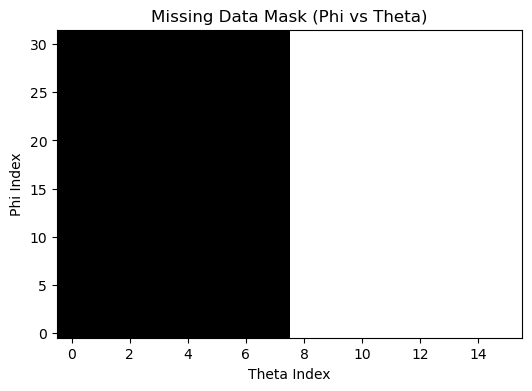

Mask applied to validation set.
Model: "AdvancedConvLSTMAttentionModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, None, 32, 16, 33)]   0         []                            
                                                                                                  
 conv3d_4 (Conv3D)           (None, None, 32, 16, 64)     57088     ['input_layer[0][0]']         
                                                                                                  
 batch_normalization_8 (Bat  (None, None, 32, 16, 64)     256       ['conv3d_4[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 max_pooling3d_4 (MaxPoolin  (None, N

__________________________________________________________________________________________________

Model compiled with Mean Squared Error loss.
X_train shape: (1000, 1, 32, 16, 33)
X_val_masked shape: (200, 1, 32, 16, 33)
y_train shape: (1000, 32, 16, 32)
y_val shape: (200, 32, 16, 32)
Epoch 1/1000

32/32 [==============================] - 14s 244ms/step - loss: 0.2560 - val_loss: 1.4913e-05
Epoch 2/1000
32/32 [==============================] - 7s 210ms/step - loss: 0.0012 - val_loss: 1.1309e-05
Epoch 3/1000
32/32 [==============================] - 7s 208ms/step - loss: 8.4030e-04 - val_loss: 8.6170e-06
Epoch 4/1000
32/32 [==============================] - 7s 210ms/step - loss: 6.6158e-04 - val_loss: 6.5504e-06
Epoch 5/1000
32/32 [==============================] - 7s 210ms/step - loss: 4.6265e-04 - val_loss: 5.0398e-06
Epoch 6/1000
32/32 [==============================] - 7s 212ms/step - loss: 3.8303e-04 - val_loss: 4.0404e-06
Epoch 7/1000
32/32 [==============================] - 7s 2

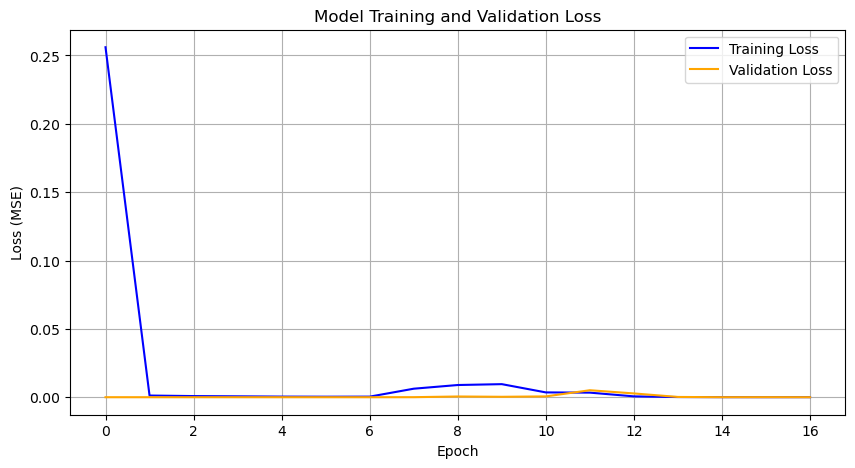

7/7 [==============================] - 1s 17ms/step


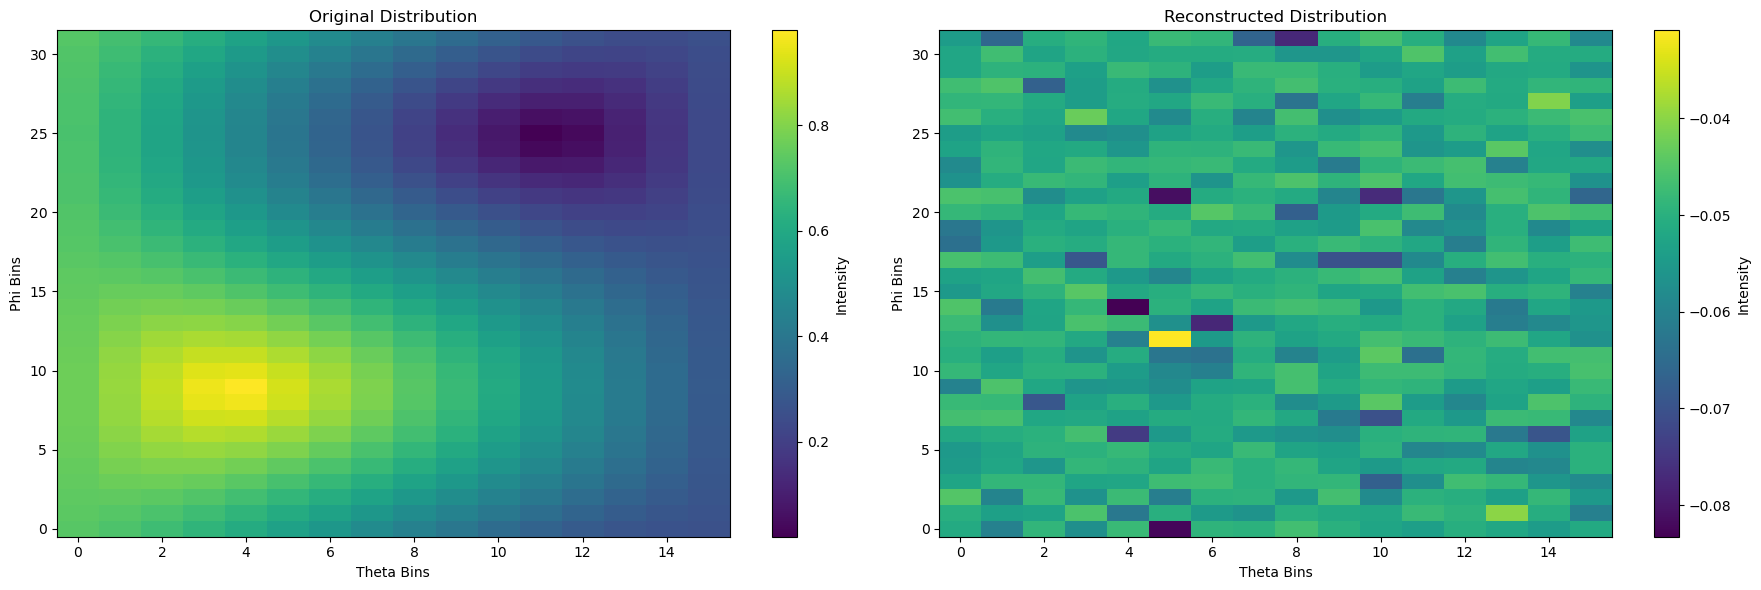


Evaluation and visualization completed.
Model saved to 'advanced_conv_lstm_attention_model_initial.h5'.


C:\Users\ryane\anaconda3\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
# ----------------------------------
# Aurora Project: Advanced Autoencoder for Single CDF Data
# ----------------------------------

import os
import datetime
import numpy as np
import cdflib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv3D, MaxPooling3D, Reshape, LSTM, Dense, BatchNormalization,
    Dropout, Attention, GlobalAveragePooling1D, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

# ----------------------------------
# 1. Define Paths and Helper Functions
# ----------------------------------

# Paths to the data folders (Update these paths as per your directory structure)
fpi_dist_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01"
fgm_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm"
fpi_moms_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//2024//03//01"

def extract_timestamp(filename):
    """
    Extract timestamp from filename.
    Assumes the timestamp is a 14-digit number (YYYYMMDDHHMMSS) part of the filename.

    Example filename: 'mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf'
    """
    try:
        parts = filename.split('_')
        for part in parts:
            if part.isdigit() and len(part) == 14:
                return datetime.datetime.strptime(part, "%Y%m%d%H%M%S")
        raise ValueError("No valid timestamp found in filename")
    except Exception as e:
        print(f"Error extracting timestamp from filename: {filename} - {e}")
        return None

def load_fgm_data(filepath):
    """Load magnetic field data from FGM CDF file."""
    with cdflib.CDF(filepath) as fgm_cdf:
        epoch = fgm_cdf.varget('Epoch')  # Time variable for FGM data
        b_gse = fgm_cdf.varget('mms1_fgm_b_gse_brst_l2')  # Magnetic field in GSE coordinates
    return epoch, b_gse

def load_fpi_dist_data(filepath):
    """Load distribution data from FPI (`des-dist`) CDF file."""
    with cdflib.CDF(filepath) as fpi_cdf:
        epoch = fpi_cdf.varget('Epoch')  # Time variable for FPI distribution data
        dist_data = fpi_cdf.varget('mms1_des_dist_brst')  # Distribution function data
        theta = fpi_cdf.varget('mms1_des_theta_brst')  # Theta angles
        phi = fpi_cdf.varget('mms1_des_phi_brst')  # Phi angles
        energy = fpi_cdf.varget('mms1_des_energy_brst')  # Energy levels
    return epoch, dist_data, theta, phi, energy  # Return energy

def load_fpi_moms_data(filepath):
    """Load bulk velocity data from FPI (`des-moms`) CDF file."""
    with cdflib.CDF(filepath) as moms_cdf:
        epoch = moms_cdf.varget('Epoch')  # Time variable for FPI moments data
        bulk_velocity = moms_cdf.varget('mms1_des_bulkv_gse_brst')  # Bulk velocity in GSE coordinates
    return epoch, bulk_velocity

def interpolate_b_field(fgm_epoch, b_gse, fpi_epoch):
    """Interpolate magnetic field data to match FPI timestamps."""
    # Extract only the first three components (x, y, z) from b_gse to match bulk velocity shape
    b_gse = b_gse[:, :3]
    interpolator = interp1d(fgm_epoch, b_gse, axis=0, bounds_error=False, fill_value="extrapolate")
    return interpolator(fpi_epoch)

def calculate_pitch_angle(phi_bins, theta_bins, b_field):
    """Calculate pitch angle distribution using look direction (phi, theta) and magnetic field."""
    # Convert theta and phi to radians
    theta_rad = np.deg2rad(theta_bins)  # Shape: (theta_bins,)
    phi_rad = np.deg2rad(phi_bins)      # Shape: (phi_bins,)

    # Create meshgrid for phi and theta
    phi_grid, theta_grid = np.meshgrid(phi_rad, theta_rad, indexing='ij')  # Shapes: (phi_bins, theta_bins)

    # Compute look direction unit vector components
    look_direction_x = np.sin(theta_grid) * np.cos(phi_grid)
    look_direction_y = np.sin(theta_grid) * np.sin(phi_grid)
    look_direction_z = np.cos(theta_grid)

    # Stack components to form the look direction vectors
    look_direction = np.stack(
        [look_direction_x, look_direction_y, look_direction_z],
        axis=2
    )  # Shape: (phi_bins, theta_bins, 3)

    # Flatten look_direction for efficient computation
    look_direction_flat = look_direction.reshape(-1, 3)  # Shape: (phi_bins * theta_bins, 3)

    # Initialize the pitch angles array
    time_steps = b_field.shape[0]
    pitch_angles = np.zeros((time_steps, phi_bins.size, theta_bins.size))  # Shape: (time_steps, phi_bins, theta_bins)

    # Iterate over each time step
    for t in range(time_steps):
        # Normalize magnetic field vector
        b_vector = b_field[t, :3]  # Assuming b_field has shape (time_steps, 3)
        b_magnitude = np.linalg.norm(b_vector)
        if b_magnitude == 0:
            b_unit = np.zeros(3)
        else:
            b_unit = b_vector / b_magnitude

        # Compute dot product between look direction and magnetic field
        v_dot_b = np.dot(look_direction_flat, b_unit)  # Shape: (phi_bins * theta_bins,)
        v_dot_b = np.clip(v_dot_b, -1.0, 1.0)  # Ensure values are within valid range

        # Calculate pitch angles in degrees
        pitch_angles_flat = np.arccos(v_dot_b) * (180.0 / np.pi)

        # Reshape back to (phi_bins, theta_bins)
        pitch_angles[t] = pitch_angles_flat.reshape(phi_bins.size, theta_bins.size)

    return pitch_angles  # Shape: (time_steps, phi_bins, theta_bins)

# ----------------------------------
# 2. Match and Select the First Matched File Set
# ----------------------------------

def match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder):
    """
    Match distribution, magnetic field, and moments CDF files based on their timestamps.

    Returns:
    - matched_files (list of tuples): Each tuple contains (timestamp, fpi_dist_file, fgm_file, fpi_moms_file)
    """
    matched_files = []
    fpi_dist_files = [f for f in os.listdir(fpi_dist_folder) if f.endswith('.cdf')]

    for fpi_dist_filename in fpi_dist_files:
        fpi_dist_timestamp = extract_timestamp(fpi_dist_filename)
        if fpi_dist_timestamp is None:
            continue

        # Find matching FGM file
        fgm_files = [f for f in os.listdir(fgm_folder) if f.endswith('.cdf')]
        matching_fgm = [f for f in fgm_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_fgm:
            print(f"No matching FGM file for timestamp {fpi_dist_timestamp}")
            continue
        fgm_filename = matching_fgm[0]

        # Find matching FPI Moments file
        fpi_moms_files = [f for f in os.listdir(fpi_moms_folder) if f.endswith('.cdf')]
        matching_moms = [f for f in fpi_moms_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_moms:
            print(f"No matching FPI Moments file for timestamp {fpi_dist_timestamp}")
            continue
        fpi_moms_filename = matching_moms[0]

        matched_files.append((fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename))

    return matched_files

# Perform file matching
matched_files = match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder)

# Check if any matched files exist
if not matched_files:
    raise FileNotFoundError("No matched file sets found.")

# Select the first matched set for processing
first_match = matched_files[0]
fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename = first_match

print("\nSelected First Matched File Set:")
print(f"  FPI Distribution File: {fpi_dist_filename}")
print(f"  FGM File: {fgm_filename}")
print(f"  FPI Moments File: {fpi_moms_filename}")

# Paths to the matched files
fpi_dist_filepath = os.path.join(fpi_dist_folder, fpi_dist_filename)
fgm_filepath = os.path.join(fgm_folder, fgm_filename)
fpi_moms_filepath = os.path.join(fpi_moms_folder, fpi_moms_filename)

# ----------------------------------
# 3. Load and Preprocess Data from the Matched File Set
# ----------------------------------

# Load FGM data
fgm_epoch, b_gse = load_fgm_data(fgm_filepath)
print("\nLoaded FGM data.")

# Load FPI Distribution data
fpi_epoch, dist_data, theta, phi, energy = load_fpi_dist_data(fpi_dist_filepath)  # Get energy
print("Loaded FPI Distribution data.")

# Load FPI Moments data
moms_epoch, bulk_velocity = load_fpi_moms_data(fpi_moms_filepath)
print("Loaded FPI Moments data.")

# Interpolate magnetic field to match FPI timestamps
b_gse_interp = interpolate_b_field(fgm_epoch, b_gse, fpi_epoch)
print("Interpolated magnetic field data to match FPI timestamps.")

# Prepare phi_bins and theta_bins
# Since phi and theta dimensions remain constant, extract them directly
# Check the shape of phi and theta to ensure they are 1D
if phi.ndim == 1:
    phi_bins = phi.flatten()  # Shape: (phi_bins=32,)
elif phi.ndim == 2:
    # If phi has a time dimension, extract from the first time step
    phi_bins = phi[0].flatten()
    print("Phi has an extra time dimension. Extracted phi from the first time step.")
else:
    raise ValueError("Unexpected shape for phi_bins.")

if theta.ndim == 1:
    theta_bins = theta.flatten()  # Shape: (theta_bins=16,)
elif theta.ndim == 2:
    # If theta has a time dimension, extract from the first time step
    theta_bins = theta[0].flatten()
    print("Theta has an extra time dimension. Extracted theta from the first time step.")
else:
    raise ValueError("Unexpected shape for theta_bins.")

# Verify shapes
print(f"Phi bins shape: {phi_bins.shape}")     # Expected: (32,)
print(f"Theta bins shape: {theta_bins.shape}") # Expected: (16,)

# Compute pitch angles using the provided function
pitch_angles = calculate_pitch_angle(phi_bins, theta_bins, b_gse_interp)
print("Calculated pitch angles.")

# Do not transpose pitch_angles; keep (time_steps, phi_bins, theta_bins)
print(f"pitch_angles shape: {pitch_angles.shape}")  # Should be (4333,32,16)

# Normalize pitch angles to [0, 1] for input to the model
pitch_angles_normalized = pitch_angles / 180.0  # Shape: (4333,32,16)

# Transpose distribution data to (time_steps, phi_bins, theta_bins, energy_levels)
# Original shape: (time_steps, energy_levels=32, phi_bins=32, theta_bins=16)
dist_data_transposed = dist_data.transpose(0, 3, 2, 1)  # Swap axes 1 and 3 to get (4333,32,16,32)
print(f"Transposed Distribution Data Shape: {dist_data_transposed.shape}")  # Should be (4333,32,16,32)

# Ensure that pitch_angles and dist_data_transposed have matching phi_bins and theta_bins
if pitch_angles_normalized.shape[1] != dist_data_transposed.shape[1] or \
   pitch_angles_normalized.shape[2] != dist_data_transposed.shape[2]:
    raise ValueError("Mismatch in phi_bins or theta_bins dimensions between pitch_angles and dist_data_transposed.")

# Expand pitch_angles to add a new feature (energy_levels +1)
pitch_angles_expanded = pitch_angles_normalized[..., np.newaxis]  # Shape: (4333,32,16,1)
print(f"Pitch Angles Expanded Shape: {pitch_angles_expanded.shape}")  # Shape: (4333,32,16,1)

# Concatenate distribution data and pitch angles along the energy_levels axis
X_data = np.concatenate((
    dist_data_transposed,
    pitch_angles_expanded
), axis=3)  # Shape: (4333,32,16,33)
X_data = X_data.astype('float32')
print(f"Input Data Shape with Pitch Angles: {X_data.shape}")  # Should be (4333,32,16,33)

# ----------------------------------
# 4. Split Data into Training, Validation, and Test Sets
# ----------------------------------

# Define split sizes
n_train = 1000  # Number of training samples
k_val = 200     # Number of validation samples
k_test = 200    # Number of test samples

if n_train + k_val + k_test > X_data.shape[0]:
    raise ValueError("Not enough data in the file for specified split sizes.")

X_train = X_data[:n_train]
X_val = X_data[n_train:n_train + k_val]
X_test = X_data[n_train + k_val:n_train + k_val + k_test]

print(f"\nTraining samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}, Test samples: {X_test.shape[0]}")

# Reshape data to include time_steps=1
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1], X_train.shape[2], X_train.shape[3]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1], X_test.shape[2], X_test.shape[3]))

print(f"Reshaped Training Data Shape: {X_train.shape}")  # (1000,1,32,16,33)
print(f"Reshaped Validation Data Shape: {X_val.shape}")  # (200,1,32,16,33)
print(f"Reshaped Test Data Shape: {X_test.shape}")        # (200,1,32,16,33)

# ----------------------------------
# 5. Apply Mask to the Validation Set
# ----------------------------------

# Create a 2D mask for phi_bins x theta_bins
mask_2d = np.zeros((X_data.shape[1], X_data.shape[2]), dtype=bool)
mask_2d[:, X_data.shape[2]//2:] = True  # Masking the right half

# Visualize the mask for one energy level (optional)
plt.figure(figsize=(6, 4))
plt.imshow(mask_2d, aspect='auto', origin='lower', cmap='gray')
plt.title('Missing Data Mask (Phi vs Theta)')
plt.xlabel('Theta Index')
plt.ylabel('Phi Index')
plt.show()

# Function to apply mask
def apply_mask(X, mask):
    """
    Apply a 2D mask to the distribution data channel.

    Parameters:
    - X: Input data array of shape (samples, time_steps, phi_bins, theta_bins, channels)
    - mask: 2D boolean array of shape (phi_bins, theta_bins)

    Returns:
    - X_masked: Masked data array
    """
    # Expand mask dimensions to match X shape
    mask_expanded = mask[np.newaxis, np.newaxis, :, :, np.newaxis]  # (1, 1, phi_bins, theta_bins, 1)
    mask_broadcast = np.tile(mask_expanded, (X.shape[0], X.shape[1], 1, 1, X.shape[4]))  # (samples, time_steps, phi_bins, theta_bins, channels)

    # Set masked regions to 0.0 in the distribution data channel (channel 0)
    X_masked = X.copy()
    X_masked[..., 0][mask_broadcast[..., 0]] = 0.0

    return X_masked

# Apply mask to validation set
X_val_masked = apply_mask(X_val, mask_2d)
print("Mask applied to validation set.")

# ----------------------------------
# 6. Define the New Model Architecture
# ----------------------------------

def build_new_model(phi_bins=32, theta_bins=16, energy_levels=32):
    """
    Build the new model architecture as specified.

    Parameters:
    - phi_bins: Number of phi bins.
    - theta_bins: Number of theta bins.
    - energy_levels: Number of energy levels.

    Returns:
    - model: Compiled Keras model.
    """
    # Define the input shape with variable time steps
    inputs = Input(shape=(None, phi_bins, theta_bins, energy_levels + 1), name='input_layer')  # +1 for pitch_angles

    # General Feature Extraction (Conv3D Block 1)
    x = Conv3D(filters=64, kernel_size=(3, 3, 3), activation='relu', padding="same")(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 2), padding="same")(x)  # Pool only spatial dimensions

    x = Conv3D(filters=128, kernel_size=(3, 3, 3), activation='relu', padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 2), padding="same")(x)

    # Intermediate Feature Extraction (Conv3D Block 2)
    x = Conv3D(filters=256, kernel_size=(3, 3, 3), activation='relu', padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 2), padding="same")(x)

    x = Conv3D(filters=512, kernel_size=(3, 3, 3), activation='relu', padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 1), padding="same")(x)  # Avoid aggressive shrinking

    # Reshape Conv3D output for LSTM
    # Use Lambda layer to handle dynamic dimensions
    def reshape_for_lstm(tensor):
        shape = K.shape(tensor)
        batch_size, time_steps, new_phi, new_theta, channels = shape[0], shape[1], shape[2], shape[3], shape[4]
        return K.reshape(tensor, (batch_size, time_steps, new_phi * new_theta * channels))

    x = Lambda(reshape_for_lstm)(x)  # Shape: (batch_size, time_steps, new_phi * new_theta * channels)

    # Temporal Modeling (LSTM Block)
    x = LSTM(units=512, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = LSTM(units=256, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Extra LSTM for Rare Events
    x = LSTM(units=128, return_sequences=True)(x)
    x = BatchNormalization()(x)

    # Attention Mechanism for Rare Events
    attention1 = Attention()([x, x])  # Self-attention
    attention2 = Attention()([attention1, attention1])  # Refine focus

    x = GlobalAveragePooling1D()(attention2)

    # Fully Connected Layers for Reconstruction
    x = Dense(units=phi_bins * theta_bins * energy_levels, activation='relu')(x)
    x = BatchNormalization()(x)
    outputs = Reshape((phi_bins, theta_bins, energy_levels))(x)

    # Model definition
    model = Model(inputs=inputs, outputs=outputs, name='AdvancedConvLSTMAttentionModel')
    return model

# Instantiate the model with corrected phi_bins and theta_bins
model = build_new_model(phi_bins=32, theta_bins=16, energy_levels=32)
model.summary()

# ----------------------------------
# 7. Compile the Model
# ----------------------------------

# Compile the model with Mean Squared Error loss
model.compile(optimizer='adam', loss='mean_squared_error')
print("\nModel compiled with Mean Squared Error loss.")

# ----------------------------------
# 8. Train the Model
# ----------------------------------

# Set up early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss for stopping
    patience=10,               # Number of epochs with no improvement after which to stop
    restore_best_weights=True  # Restore the best weights after stopping
)

# Define training parameters
epochs = 1000  # Adjust as needed
batch_size = 32

# Prepare training and validation targets
# Target is the PSD cube (channels 0 to 31)
y_train = X_train[..., :-1]  # All channels except the last one (pitch_angles) => Shape: (1000,1,32,16,32)
y_val = X_val_masked[..., :-1]      # All channels except the last one (pitch_angles) => Shape: (200,1,32,16,32)

# Reshape targets to match output shape
# Model output shape: (batch_size, phi_bins=32, theta_bins=16, energy_levels=32)
y_train = y_train[:, 0, :, :, :]  # Shape: (1000,32,16,32)
y_val = y_val[:, 0, :, :, :]      # Shape: (200,32,16,32)

# Verify shapes
print(f"X_train shape: {X_train.shape}")          # Expected: (1000,1,32,16,33)
print(f"X_val_masked shape: {X_val_masked.shape}")# Expected: (200,1,32,16,33)
print(f"y_train shape: {y_train.shape}")          # Expected: (1000,32,16,32)
print(f"y_val shape: {y_val.shape}")              # Expected: (200,32,16,32) 

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,  # Shuffle the data
    validation_data=(X_val_masked, y_val),
    callbacks=[early_stopping]  # Apply early stopping
)

print("\nModel training completed.")

# ----------------------------------
# 9. Visualize Training Progress
# ----------------------------------

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------
# 10. Evaluate and Visualize Model Performance
# ----------------------------------

# Make predictions on the test set
X_test_pred = model.predict(X_test)  # Shape: (200,32,16,32)

# Visualize original vs. reconstructed data for a sample
sample_index = 0  # Change as needed (0 to k_test-1)

# Original Distribution Data (Unmasked)
original_distribution = np.sum(X_test[sample_index, 0, :, :, :], axis=2)  # Sum over energy levels => Shape: (32,16)

# Reconstructed Distribution Data
reconstructed_distribution = np.sum(X_test_pred[sample_index, :, :, :], axis=2)  # Sum over energy levels => Shape: (32,16)

# Plotting
plt.figure(figsize=(18, 6))

# Plot Original
plt.subplot(1, 2, 1)
plt.imshow(original_distribution, aspect='auto', origin='lower', cmap='viridis')
plt.title('Original Distribution')
plt.xlabel('Theta Bins')
plt.ylabel('Phi Bins')
plt.colorbar(label='Intensity')

# Plot Reconstructed
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_distribution, aspect='auto', origin='lower', cmap='viridis')
plt.title('Reconstructed Distribution')
plt.xlabel('Theta Bins')
plt.ylabel('Phi Bins')
plt.colorbar(label='Intensity')

plt.tight_layout()
plt.show()

print("\nEvaluation and visualization completed.")

# ----------------------------------
# 11. Save the Trained Model (Optional)
# ----------------------------------

# Save the trained model
model.save('advanced_conv_lstm_attention_model_initial.h5')
print("Model saved to 'advanced_conv_lstm_attention_model_initial.h5'.")

# To load the model later, use:
# from tensorflow.keras.models import load_model
# loaded_model = load_model('advanced_conv_lstm_attention_model_initial.h5')


# Attempt 2

No matching FPI Moments file for timestamp 2024-03-01 23:22:33
No matching FPI Moments file for timestamp 2024-03-01 23:29:13

Selected First Matched File Set:
  FPI Distribution File: mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf
  FGM File: mms1_fgm_brst_l2_20240301230743_v5.441.0.cdf
  FPI Moments File: mms1_fpi_brst_l2_des-moms_20240301230743_v3.4.0.cdf

Loaded FGM data.
Loaded FPI Distribution data.
Loaded FPI Moments data.
Interpolated magnetic field data to match FPI timestamps.
Phi has an extra time dimension. Extracted phi from the first time step.
Phi bins shape: (32,)
Theta bins shape: (16,)
Calculated pitch angles.
pitch_angles shape: (4333, 32, 16)
Transposed Distribution Data Shape: (4333, 32, 16, 32)
Pitch Angles Expanded Shape: (4333, 32, 16, 1)
Input Data Shape with Pitch Angles: (4333, 32, 16, 33)

Total samples: 4333
Training samples: 2166, Validation samples: 1083, Test samples: 1084
Training Data Shape: (2166, 32, 16, 33)
Validation Data Shape: (1083, 32, 16,

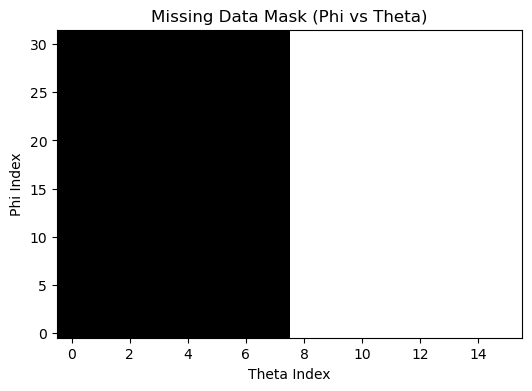

Mask applied to test set.
Model: "AdvancedConvLSTMAttentionModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_layer (InputLayer)    [(None, None, 32, 16, 33)]   0         []                            
                                                                                                  
 conv3d_8 (Conv3D)           (None, None, 32, 16, 64)     57088     ['input_layer[0][0]']         
                                                                                                  
 batch_normalization_16 (Ba  (None, None, 32, 16, 64)     256       ['conv3d_8[0][0]']            
 tchNormalization)                                                                                
                                                                                                  
 max_pooling3d_8 (MaxPoolin  (None, None, 1

__________________________________________________________________________________________________

Model compiled with Mean Squared Error loss.
X_train shape: (2166, 1, 32, 16, 33)
X_val shape: (1083, 1, 32, 16, 33)
y_train shape: (2166, 32, 16, 32)
y_val shape: (1083, 32, 16, 32)
Epoch 1/1000
68/68 [==============================] - ETA: 0s - loss: 0.1370
Epoch 1: val_loss improved from inf to 0.00002, saving model to best_model.h5
68/68 [==============================] - 22s 232ms/step - loss: 0.1370 - val_loss: 1.7718e-05
Epoch 2/1000
68/68 [==============================] - ETA: 0s - loss: 0.0011
Epoch 2: val_loss improved from 0.00002 to 0.00001, saving model to best_model.h5
68/68 [==============================] - 15s 221ms/step - loss: 0.0011 - val_loss: 9.7374e-06
Epoch 3/1000
68/68 [==============================] - ETA: 0s - loss: 7.5995e-04
Epoch 3: val_loss improved from 0.00001 to 0.00001, saving model to best_model.h5
68/68 [==============================] - 15s 221ms/s

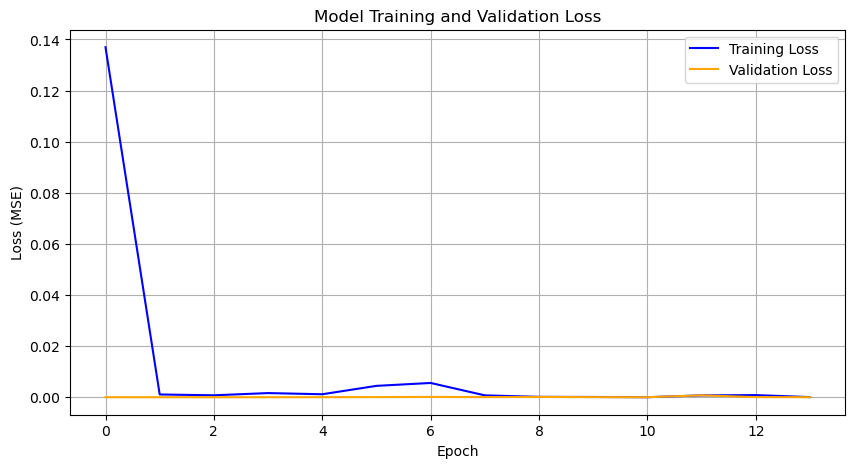

34/34 [==============================] - 1s 18ms/step


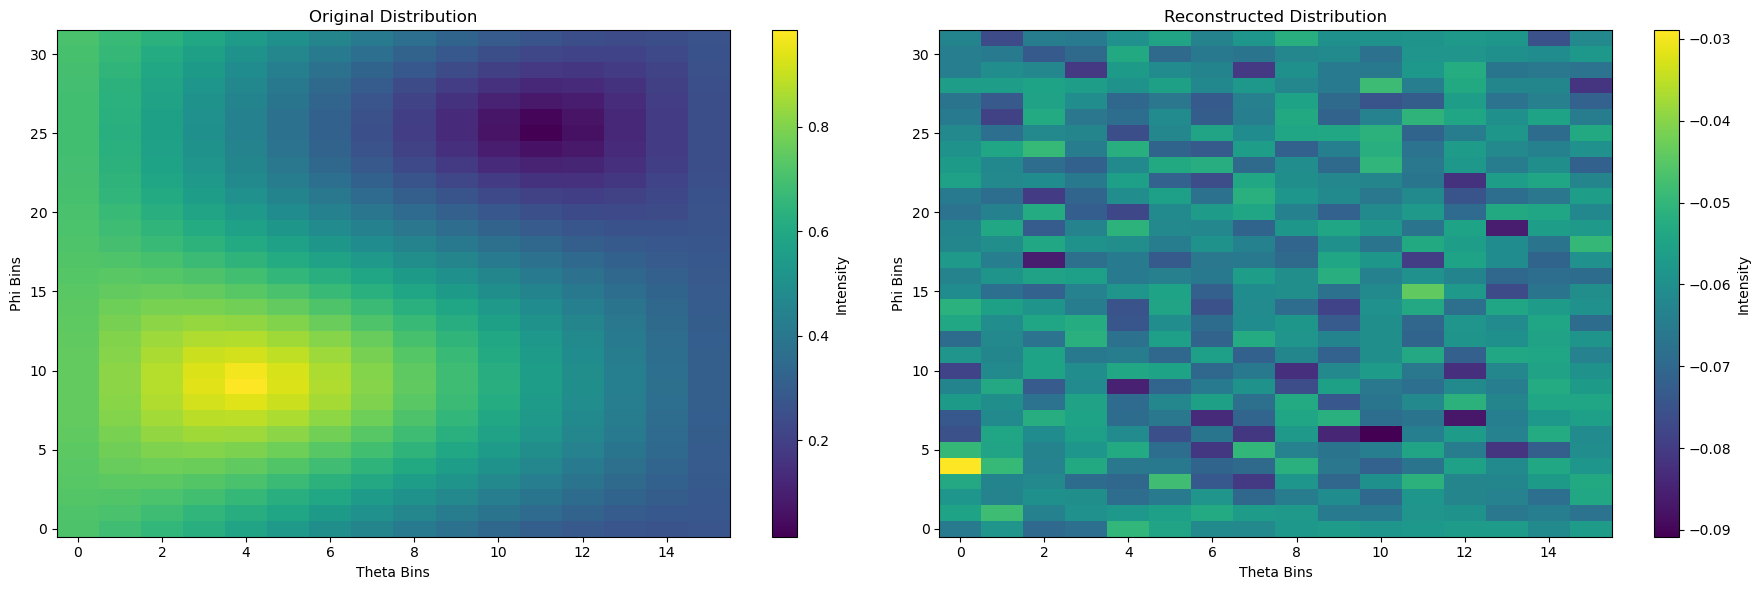


Evaluation and visualization completed.
Model saved to 'advanced_conv_lstm_attention_model_initial.h5'.


In [11]:
# ----------------------------------
# Aurora Project: Advanced Autoencoder for Single CDF Data
# ----------------------------------

import os
import datetime
import numpy as np
import cdflib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv3D, MaxPooling3D, Reshape, LSTM, Dense, BatchNormalization,
    Dropout, Attention, GlobalAveragePooling1D, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

# ----------------------------------
# 1. Define Paths and Helper Functions
# ----------------------------------

# Paths to the data folders (Update these paths as per your directory structure)
fpi_dist_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01"
fgm_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm"
fpi_moms_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//2024//03//01"

def extract_timestamp(filename):
    """
    Extract timestamp from filename.
    Assumes the timestamp is a 14-digit number (YYYYMMDDHHMMSS) part of the filename.

    Example filename: 'mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf'
    """
    try:
        parts = filename.split('_')
        for part in parts:
            if part.isdigit() and len(part) == 14:
                return datetime.datetime.strptime(part, "%Y%m%d%H%M%S")
        raise ValueError("No valid timestamp found in filename")
    except Exception as e:
        print(f"Error extracting timestamp from filename: {filename} - {e}")
        return None

def load_fgm_data(filepath):
    """Load magnetic field data from FGM CDF file."""
    with cdflib.CDF(filepath) as fgm_cdf:
        epoch = fgm_cdf.varget('Epoch')  # Time variable for FGM data
        b_gse = fgm_cdf.varget('mms1_fgm_b_gse_brst_l2')  # Magnetic field in GSE coordinates
    return epoch, b_gse

def load_fpi_dist_data(filepath):
    """Load distribution data from FPI (`des-dist`) CDF file."""
    with cdflib.CDF(filepath) as fpi_cdf:
        epoch = fpi_cdf.varget('Epoch')  # Time variable for FPI distribution data
        dist_data = fpi_cdf.varget('mms1_des_dist_brst')  # Distribution function data
        theta = fpi_cdf.varget('mms1_des_theta_brst')  # Theta angles
        phi = fpi_cdf.varget('mms1_des_phi_brst')  # Phi angles
        energy = fpi_cdf.varget('mms1_des_energy_brst')  # Energy levels
    return epoch, dist_data, theta, phi, energy  # Return energy

def load_fpi_moms_data(filepath):
    """Load bulk velocity data from FPI (`des-moms`) CDF file."""
    with cdflib.CDF(filepath) as moms_cdf:
        epoch = moms_cdf.varget('Epoch')  # Time variable for FPI moments data
        bulk_velocity = moms_cdf.varget('mms1_des_bulkv_gse_brst')  # Bulk velocity in GSE coordinates
    return epoch, bulk_velocity

def interpolate_b_field(fgm_epoch, b_gse, fpi_epoch):
    """Interpolate magnetic field data to match FPI timestamps."""
    # Extract only the first three components (x, y, z) from b_gse to match bulk velocity shape
    b_gse = b_gse[:, :3]
    interpolator = interp1d(fgm_epoch, b_gse, axis=0, bounds_error=False, fill_value="extrapolate")
    return interpolator(fpi_epoch)

def calculate_pitch_angle(phi_bins, theta_bins, b_field):
    """Calculate pitch angle distribution using look direction (phi, theta) and magnetic field."""
    # Convert theta and phi to radians
    theta_rad = np.deg2rad(theta_bins)  # Shape: (theta_bins,)
    phi_rad = np.deg2rad(phi_bins)      # Shape: (phi_bins,)

    # Create meshgrid for phi and theta
    phi_grid, theta_grid = np.meshgrid(phi_rad, theta_rad, indexing='ij')  # Shapes: (phi_bins, theta_bins)

    # Compute look direction unit vector components
    look_direction_x = np.sin(theta_grid) * np.cos(phi_grid)
    look_direction_y = np.sin(theta_grid) * np.sin(phi_grid)
    look_direction_z = np.cos(theta_grid)

    # Stack components to form the look direction vectors
    look_direction = np.stack(
        [look_direction_x, look_direction_y, look_direction_z],
        axis=2
    )  # Shape: (phi_bins, theta_bins, 3)

    # Flatten look_direction for efficient computation
    look_direction_flat = look_direction.reshape(-1, 3)  # Shape: (phi_bins * theta_bins, 3)

    # Initialize the pitch angles array
    time_steps = b_field.shape[0]
    pitch_angles = np.zeros((time_steps, phi_bins.size, theta_bins.size))  # Shape: (time_steps, phi_bins, theta_bins)

    # Iterate over each time step
    for t in range(time_steps):
        # Normalize magnetic field vector
        b_vector = b_field[t, :3]  # Assuming b_field has shape (time_steps, 3)
        b_magnitude = np.linalg.norm(b_vector)
        if b_magnitude == 0:
            b_unit = np.zeros(3)
        else:
            b_unit = b_vector / b_magnitude

        # Compute dot product between look direction and magnetic field
        v_dot_b = np.dot(look_direction_flat, b_unit)  # Shape: (phi_bins * theta_bins,)
        v_dot_b = np.clip(v_dot_b, -1.0, 1.0)  # Ensure values are within valid range

        # Calculate pitch angles in degrees
        pitch_angles_flat = np.arccos(v_dot_b) * (180.0 / np.pi)

        # Reshape back to (phi_bins, theta_bins)
        pitch_angles[t] = pitch_angles_flat.reshape(phi_bins.size, theta_bins.size)

    return pitch_angles  # Shape: (time_steps, phi_bins, theta_bins)

# ----------------------------------
# 2. Match and Select the First Matched File Set
# ----------------------------------

def match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder):
    """
    Match distribution, magnetic field, and moments CDF files based on their timestamps.

    Returns:
    - matched_files (list of tuples): Each tuple contains (timestamp, fpi_dist_file, fgm_file, fpi_moms_file)
    """
    matched_files = []
    fpi_dist_files = [f for f in os.listdir(fpi_dist_folder) if f.endswith('.cdf')]

    for fpi_dist_filename in fpi_dist_files:
        fpi_dist_timestamp = extract_timestamp(fpi_dist_filename)
        if fpi_dist_timestamp is None:
            continue

        # Find matching FGM file
        fgm_files = [f for f in os.listdir(fgm_folder) if f.endswith('.cdf')]
        matching_fgm = [f for f in fgm_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_fgm:
            print(f"No matching FGM file for timestamp {fpi_dist_timestamp}")
            continue
        fgm_filename = matching_fgm[0]

        # Find matching FPI Moments file
        fpi_moms_files = [f for f in os.listdir(fpi_moms_folder) if f.endswith('.cdf')]
        matching_moms = [f for f in fpi_moms_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_moms:
            print(f"No matching FPI Moments file for timestamp {fpi_dist_timestamp}")
            continue
        fpi_moms_filename = matching_moms[0]

        matched_files.append((fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename))

    return matched_files

# Perform file matching
matched_files = match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder)

# Check if any matched files exist
if not matched_files:
    raise FileNotFoundError("No matched file sets found.")

# Select the first matched set for processing
first_match = matched_files[0]
fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename = first_match

print("\nSelected First Matched File Set:")
print(f"  FPI Distribution File: {fpi_dist_filename}")
print(f"  FGM File: {fgm_filename}")
print(f"  FPI Moments File: {fpi_moms_filename}")

# Paths to the matched files
fpi_dist_filepath = os.path.join(fpi_dist_folder, fpi_dist_filename)
fgm_filepath = os.path.join(fgm_folder, fgm_filename)
fpi_moms_filepath = os.path.join(fpi_moms_folder, fpi_moms_filename)

# ----------------------------------
# 3. Load and Preprocess Data from the Matched File Set
# ----------------------------------

# Load FGM data
fgm_epoch, b_gse = load_fgm_data(fgm_filepath)
print("\nLoaded FGM data.")

# Load FPI Distribution data
fpi_epoch, dist_data, theta, phi, energy = load_fpi_dist_data(fpi_dist_filepath)  # Get energy
print("Loaded FPI Distribution data.")

# Load FPI Moments data
moms_epoch, bulk_velocity = load_fpi_moms_data(fpi_moms_filepath)
print("Loaded FPI Moments data.")

# Interpolate magnetic field to match FPI timestamps
b_gse_interp = interpolate_b_field(fgm_epoch, b_gse, fpi_epoch)
print("Interpolated magnetic field data to match FPI timestamps.")

# Prepare phi_bins and theta_bins
# Since phi and theta dimensions remain constant, extract them directly
# Check the shape of phi and theta to ensure they are 1D
if phi.ndim == 1:
    phi_bins = phi.flatten()  # Shape: (phi_bins=32,)
elif phi.ndim == 2:
    # If phi has a time dimension, extract from the first time step
    phi_bins = phi[0].flatten()
    print("Phi has an extra time dimension. Extracted phi from the first time step.")
else:
    raise ValueError("Unexpected shape for phi_bins.")

if theta.ndim == 1:
    theta_bins = theta.flatten()  # Shape: (theta_bins=16,)
elif theta.ndim == 2:
    # If theta has a time dimension, extract from the first time step
    theta_bins = theta[0].flatten()
    print("Theta has an extra time dimension. Extracted theta from the first time step.")
else:
    raise ValueError("Unexpected shape for theta_bins.")

# Verify shapes
print(f"Phi bins shape: {phi_bins.shape}")     # Expected: (32,)
print(f"Theta bins shape: {theta_bins.shape}") # Expected: (16,)

# Compute pitch angles using the provided function
pitch_angles = calculate_pitch_angle(phi_bins, theta_bins, b_gse_interp)
print("Calculated pitch angles.")

# Do not transpose pitch_angles; keep (time_steps, phi_bins, theta_bins)
print(f"pitch_angles shape: {pitch_angles.shape}")  # Should be (4333,32,16)

# Normalize pitch angles to [0, 1] for input to the model
pitch_angles_normalized = pitch_angles / 180.0  # Shape: (4333,32,16)

# Transpose distribution data to (time_steps, phi_bins, theta_bins, energy_levels)
# Original shape: (time_steps, energy_levels=32, phi_bins=32, theta_bins=16)
dist_data_transposed = dist_data.transpose(0, 3, 2, 1)  # Swap axes 1 and 3 to get (4333,32,16,32)
print(f"Transposed Distribution Data Shape: {dist_data_transposed.shape}")  # Should be (4333,32,16,32)

# Ensure that pitch_angles and dist_data_transposed have matching phi_bins and theta_bins
if pitch_angles_normalized.shape[1] != dist_data_transposed.shape[1] or \
   pitch_angles_normalized.shape[2] != dist_data_transposed.shape[2]:
    raise ValueError("Mismatch in phi_bins or theta_bins dimensions between pitch_angles and dist_data_transposed.")

# Expand pitch_angles to add a new feature (energy_levels +1)
pitch_angles_expanded = pitch_angles_normalized[..., np.newaxis]  # Shape: (4333,32,16,1)
print(f"Pitch Angles Expanded Shape: {pitch_angles_expanded.shape}")  # Shape: (4333,32,16,1)

# Concatenate distribution data and pitch angles along the energy_levels axis
X_data = np.concatenate((
    dist_data_transposed,
    pitch_angles_expanded
), axis=3)  # Shape: (4333,32,16,33)
X_data = X_data.astype('float32')
print(f"Input Data Shape with Pitch Angles: {X_data.shape}")  # Should be (4333,32,16,33)

# ----------------------------------
# 4. Split Data into Training, Validation, and Test Sets
# ----------------------------------

# Define split proportions
total_samples = X_data.shape[0]
n_train = int(0.5 * total_samples)     # 50% Training
k_val = int(0.25 * total_samples)      # 25% Validation
k_test = total_samples - n_train - k_val  # Remaining 25% Test

print(f"\nTotal samples: {total_samples}")
print(f"Training samples: {n_train}, Validation samples: {k_val}, Test samples: {k_test}")

# Split the data
X_train = X_data[:n_train]
X_val = X_data[n_train:n_train + k_val]
X_test = X_data[n_train + k_val:]

print(f"Training Data Shape: {X_train.shape}")    # (n_train,32,16,33)
print(f"Validation Data Shape: {X_val.shape}")    # (k_val,32,16,33)
print(f"Test Data Shape: {X_test.shape}")          # (k_test,32,16,33)

# Reshape data to include time_steps=1
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1], X_train.shape[2], X_train.shape[3]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1], X_val.shape[2], X_val.shape[3]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1], X_test.shape[2], X_test.shape[3]))

print(f"Reshaped Training Data Shape: {X_train.shape}")  # (n_train,1,32,16,33)
print(f"Reshaped Validation Data Shape: {X_val.shape}")  # (k_val,1,32,16,33)
print(f"Reshaped Test Data Shape: {X_test.shape}")        # (k_test,1,32,16,33)

# ----------------------------------
# 5. Apply Mask to the Test Set Only
# ----------------------------------

# Create a 2D mask for phi_bins x theta_bins
mask_2d = np.zeros((X_data.shape[1], X_data.shape[2]), dtype=bool)
mask_2d[:, X_data.shape[2]//2:] = True  # Masking the right half

# Visualize the mask (optional)
plt.figure(figsize=(6, 4))
plt.imshow(mask_2d, aspect='auto', origin='lower', cmap='gray')
plt.title('Missing Data Mask (Phi vs Theta)')
plt.xlabel('Theta Index')
plt.ylabel('Phi Index')
plt.show()

# Function to apply mask
def apply_mask(X, mask):
    """
    Apply a 2D mask to the distribution data channel.

    Parameters:
    - X: Input data array of shape (samples, time_steps, phi_bins, theta_bins, channels)
    - mask: 2D boolean array of shape (phi_bins, theta_bins)

    Returns:
    - X_masked: Masked data array
    """
    # Expand mask dimensions to match X shape
    mask_expanded = mask[np.newaxis, np.newaxis, :, :, np.newaxis]  # (1, 1, phi_bins, theta_bins, 1)
    mask_broadcast = np.tile(mask_expanded, (X.shape[0], X.shape[1], 1, 1, X.shape[4]))  # (samples, time_steps, phi_bins, theta_bins, channels)

    # Set masked regions to 0.0 in the distribution data channel (channel 0)
    X_masked = X.copy()
    X_masked[..., 0][mask_broadcast[..., 0]] = 0.0

    return X_masked

# Apply mask to the test set only
X_test_masked = apply_mask(X_test, mask_2d)
print("Mask applied to test set.")

# ----------------------------------
# 6. Define the New Model Architecture
# ----------------------------------

def build_new_model(phi_bins=32, theta_bins=16, energy_levels=32):
    """
    Build the new model architecture as specified.

    Parameters:
    - phi_bins: Number of phi bins.
    - theta_bins: Number of theta bins.
    - energy_levels: Number of energy levels.

    Returns:
    - model: Compiled Keras model.
    """
    # Define the input shape with variable time steps
    inputs = Input(shape=(None, phi_bins, theta_bins, energy_levels + 1), name='input_layer')  # +1 for pitch_angles

    # General Feature Extraction (Conv3D Block 1)
    x = Conv3D(filters=64, kernel_size=(3, 3, 3), activation='relu', padding="same")(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 2), padding="same")(x)  # Pool only spatial dimensions

    x = Conv3D(filters=128, kernel_size=(3, 3, 3), activation='relu', padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 2), padding="same")(x)

    # Intermediate Feature Extraction (Conv3D Block 2)
    x = Conv3D(filters=256, kernel_size=(3, 3, 3), activation='relu', padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 2), padding="same")(x)

    x = Conv3D(filters=512, kernel_size=(3, 3, 3), activation='relu', padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling3D(pool_size=(1, 2, 1), padding="same")(x)  # Avoid aggressive shrinking

    # Reshape Conv3D output for LSTM
    # Use Lambda layer to handle dynamic dimensions
    def reshape_for_lstm(tensor):
        shape = K.shape(tensor)
        batch_size, time_steps, new_phi, new_theta, channels = shape[0], shape[1], shape[2], shape[3], shape[4]
        return K.reshape(tensor, (batch_size, time_steps, new_phi * new_theta * channels))

    x = Lambda(reshape_for_lstm)(x)  # Shape: (batch_size, time_steps, new_phi * new_theta * channels)

    # Temporal Modeling (LSTM Block)
    x = LSTM(units=512, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = LSTM(units=256, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Extra LSTM for Rare Events
    x = LSTM(units=128, return_sequences=True)(x)
    x = BatchNormalization()(x)

    # Attention Mechanism for Rare Events
    attention1 = Attention()([x, x])  # Self-attention
    attention2 = Attention()([attention1, attention1])  # Refine focus

    x = GlobalAveragePooling1D()(attention2)

    # Fully Connected Layers for Reconstruction
    x = Dense(units=phi_bins * theta_bins * energy_levels, activation='relu')(x)
    x = BatchNormalization()(x)
    outputs = Reshape((phi_bins, theta_bins, energy_levels))(x)

    # Model definition
    model = Model(inputs=inputs, outputs=outputs, name='AdvancedConvLSTMAttentionModel')
    return model

# Instantiate the model with corrected phi_bins and theta_bins
model = build_new_model(phi_bins=32, theta_bins=16, energy_levels=32)
model.summary()

# ----------------------------------
# 7. Compile the Model
# ----------------------------------

# Compile the model with Mean Squared Error loss
model.compile(optimizer='adam', loss='mean_squared_error')
print("\nModel compiled with Mean Squared Error loss.")

# ----------------------------------
# 8. Train the Model
# ----------------------------------

# Set up early stopping and model checkpointing
early_stopping = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss for stopping
    patience=10,               # Number of epochs with no improvement after which to stop
    restore_best_weights=True  # Restore the best weights after stopping
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Define training parameters
epochs = 1000  # Adjust as needed
batch_size = 32

# Prepare training and validation targets
# Target is the PSD cube (channels 0 to 31)
y_train = X_train[..., :-1]  # All channels except the last one (pitch_angles) => Shape: (n_train,1,32,16,32)
y_val = X_val[..., :-1]      # All channels except the last one (pitch_angles) => Shape: (k_val,1,32,16,32)

# Reshape targets to match output shape
# Model output shape: (batch_size, phi_bins=32, theta_bins=16, energy_levels=32)
y_train = y_train[:, 0, :, :, :]  # Shape: (n_train,32,16,32)
y_val = y_val[:, 0, :, :, :]      # Shape: (k_val,32,16,32)

# Verify shapes
print(f"X_train shape: {X_train.shape}")          # Expected: (2166,1,32,16,33)
print(f"X_val shape: {X_val.shape}")              # Expected: (1083,1,32,16,33)
print(f"y_train shape: {y_train.shape}")          # Expected: (2166,32,16,32)
print(f"y_val shape: {y_val.shape}")              # Expected: (1083,32,16,32) 

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,  # Shuffle the data
    validation_data=(X_val, y_val),  # Validation set is unmasked
    callbacks=[early_stopping, checkpoint]  # Apply early stopping and checkpoint
)

print("\nModel training completed.")

# ----------------------------------
# 9. Visualize Training Progress
# ----------------------------------

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------
# 10. Evaluate and Visualize Model Performance
# ----------------------------------

# Make predictions on the test set
X_test_pred = model.predict(X_test_masked)  # Shape: (k_test,32,16,32)

# Visualize original vs. reconstructed data for a sample
sample_index = 0  # Change as needed (0 to k_test-1)

# Original Distribution Data (Unmasked)
original_distribution = np.sum(X_test[sample_index, 0, :, :, :], axis=2)  # Sum over energy levels => Shape: (32,16)

# Reconstructed Distribution Data
reconstructed_distribution = np.sum(X_test_pred[sample_index, :, :, :], axis=2)  # Sum over energy levels => Shape: (32,16)

# Plotting
plt.figure(figsize=(18, 6))

# Plot Original
plt.subplot(1, 2, 1)
plt.imshow(original_distribution, aspect='auto', origin='lower', cmap='viridis')
plt.title('Original Distribution')
plt.xlabel('Theta Bins')
plt.ylabel('Phi Bins')
plt.colorbar(label='Intensity')

# Plot Reconstructed
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_distribution, aspect='auto', origin='lower', cmap='viridis')
plt.title('Reconstructed Distribution')
plt.xlabel('Theta Bins')
plt.ylabel('Phi Bins')
plt.colorbar(label='Intensity')

plt.tight_layout()
plt.show()

print("\nEvaluation and visualization completed.")

# ----------------------------------
# 11. Save the Trained Model (Optional)
# ----------------------------------

# Save the trained model
model.save('advanced_conv_lstm_attention_model_initial.h5')
print("Model saved to 'advanced_conv_lstm_attention_model_initial.h5'.")

# To load the model later, use:
# from tensorflow.keras.models import load_model
# loaded_model = load_model('advanced_conv_lstm_attention_model_initial.h5')
